## BUSINESS UNDERSTANDING

### BACKGROUND

The FIFA World Cup is the world's most-watched sporting event, with over 3.5 billion viewers globally. The 2026 tournament is particularly significant as it marks:

The first 48-team tournament (expanded from 32 teams)

Hosted across 3 countries: USA, Canada, and Mexico

104 matches (up from 64) across 16 host cities

### BUSINESS CONTEXT

This challenge addresses the growing demand for data-driven insights in sports analytics. Stakeholders across the football ecosystem can benefit from predictive models that forecast tournament outcomes.

### DATA CONSTRAINTS
- Closed-data challenge: Only the Fjelstul World Cup Database
- No external data: No 2026 tournament information

- No web scraping: No betting odds, rankings, or real-time data


### OBJECTIVES
- Predict total goals for each of the 48 teams (RMSE, 60% weight)
- Predict tournament stage reached for each team (F1 Score, 40% weight)
- Minimize RMSE on the private leaderboard for goal predictions
- Classify each team into one of 7 stages: Group, Round32, Round16, QF, SF, Runner-up, Champion
- Maximize F1 Score on the private leaderboard for stage classification


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Load all files
data_dir = Path('data/')
all_files = list(data_dir.glob('*.csv'))

# Create dictionary of dataframes
dfs = {}
for file in all_files:
    name = file.stem
    dfs[name] = pd.read_csv(file)
    print(f"{name:25s} : {len(dfs[name]):5d} rows, {len(dfs[name].columns):2d} columns")

awards                    :     8 rows,  5 columns
award_winners             :   200 rows, 12 columns
bookings                  :  3178 rows, 26 columns
confederations            :     6 rows,  5 columns
goals                     :  3637 rows, 27 columns
groups                    :   159 rows,  7 columns
group_standings           :   626 rows, 19 columns
host_countries            :    31 rows,  7 columns
managers                  :   475 rows,  7 columns
manager_appearances       :  2538 rows, 17 columns
manager_appointments      :   637 rows, 10 columns
matches                   :  1248 rows, 37 columns
penalty_kicks             :   396 rows, 19 columns
players                   : 10401 rows, 13 columns
player_appearances        : 27432 rows, 21 columns
qualified_teams           :   625 rows,  8 columns
referees                  :   493 rows, 10 columns
referee_appearances       :  1248 rows, 15 columns
referee_appointments      :   668 rows, 10 columns
squads                    : 138

### Data Quality Assessment

In [14]:
def comprehensive_data_report(dfs):
    """Generate comprehensive data quality report"""
    report = []
    
    for name, df in dfs.items():
        # Basic info
        missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
        duplicate_rows = df.duplicated().sum()
        
        report.append({
            'Dataset': name,
            'Rows': df.shape[0],
            'Columns': df.shape[1],
            'Missing %': f"{missing_pct:.1f}%",
            'Duplicates': duplicate_rows,
            'Memory (MB)': df.memory_usage(deep=True).sum() / 1024**2
        })
    
    report_df = pd.DataFrame(report).sort_values('Missing %', ascending=False)
    return report_df

quality_report = comprehensive_data_report(dfs)
print("DATA QUALITY REPORT:")
display(quality_report)

# Identify datasets with high missing values
high_missing = quality_report[quality_report['Missing %'].str.rstrip('%').astype(float) > 5]
if len(high_missing) > 0:
    print("\n⚠️ Datasets with >5% missing values:")
    display(high_missing)

DATA QUALITY REPORT:


,Dataset,Rows,Columns,Missing %,Duplicates,Memory (MB)
0,awards,8,5,0.0%,0,0.000675
1,award_winners,200,12,0.0%,0,0.034243
2,bookings,3178,26,0.0%,0,1.078738
3,confederations,6,5,0.0%,0,0.000914
4,goals,3637,27,0.0%,0,1.313055
5,groups,159,7,0.0%,0,0.016397
6,group_standings,626,19,0.0%,0,0.130340
7,host_countries,31,7,0.0%,0,0.003512
8,managers,475,7,0.0%,0,0.058593
9,manager_appearances,2538,17,0.0%,0,0.649355


In [18]:
# ============================================
# CELL 1: Import Libraries & Load Data
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Data directory
data_dir = Path('data/')

# Load all datasets (already done in your notebook)
# But let's organize them for easy access
dfs = {
    'awards': pd.read_csv(data_dir / 'awards.csv'),
    'award_winners': pd.read_csv(data_dir / 'award_winners.csv'),
    'bookings': pd.read_csv(data_dir / 'bookings.csv'),
    'confederations': pd.read_csv(data_dir / 'confederations.csv'),
    'goals': pd.read_csv(data_dir / 'goals.csv'),
    'groups': pd.read_csv(data_dir / 'groups.csv'),
    'group_standings': pd.read_csv(data_dir / 'group_standings.csv'),
    'host_countries': pd.read_csv(data_dir / 'host_countries.csv'),
    'managers': pd.read_csv(data_dir / 'managers.csv'),
    'manager_appearances': pd.read_csv(data_dir / 'manager_appearances.csv'),
    'manager_appointments': pd.read_csv(data_dir / 'manager_appointments.csv'),
    'matches': pd.read_csv(data_dir / 'matches.csv'),
    'penalty_kicks': pd.read_csv(data_dir / 'penalty_kicks.csv'),
    'players': pd.read_csv(data_dir / 'players.csv'),
    'player_appearances': pd.read_csv(data_dir / 'player_appearances.csv'),
    'qualified_teams': pd.read_csv(data_dir / 'qualified_teams.csv'),
    'referees': pd.read_csv(data_dir / 'referees.csv'),
    'referee_appearances': pd.read_csv(data_dir / 'referee_appearances.csv'),
    'referee_appointments': pd.read_csv(data_dir / 'referee_appointments.csv'),
    'squads': pd.read_csv(data_dir / 'squads.csv'),
    'stadiums': pd.read_csv(data_dir / 'stadiums.csv'),
    'substitutions': pd.read_csv(data_dir / 'substitutions.csv'),
    'teams': pd.read_csv(data_dir / 'teams.csv'),
    'team_appearances': pd.read_csv(data_dir / 'team_appearances.csv'),
    'tournaments': pd.read_csv(data_dir / 'tournaments.csv'),
    'tournament_stages': pd.read_csv(data_dir / 'tournament_stages.csv'),
    'tournament_standings': pd.read_csv(data_dir / 'tournament_standings.csv')
}

print("✅ All datasets loaded successfully!")
print(f"Total datasets: {len(dfs)}")

# Show dataset sizes
print("\n📊 Dataset Overview:")
overview = []
for name, df in dfs.items():
    overview.append({
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Memory (MB)': df.memory_usage(deep=True).sum() / 1024**2
    })
overview_df = pd.DataFrame(overview).sort_values('Rows', ascending=False)
display(overview_df)

# Identify core datasets for prediction
core_datasets = ['team_appearances', 'teams', 'tournaments', 'matches', 'goals', 
                 'tournament_stages', 'tournament_standings', 'confederations', 'host_countries']
print("\n🎯 Core datasets for prediction:")
for ds in core_datasets:
    print(f"  • {ds}: {dfs[ds].shape[0]} rows, {dfs[ds].shape[1]} columns")

✅ All datasets loaded successfully!
Total datasets: 27

📊 Dataset Overview:


,Dataset,Rows,Columns,Memory (MB)
14,player_appearances,27432,21,8.041348
19,squads,13843,12,2.303242
13,players,10401,13,1.860174
21,substitutions,10222,24,3.305119
4,goals,3637,27,1.313055
2,bookings,3178,26,1.078738
9,manager_appearances,2538,17,0.649355
23,team_appearances,2496,36,1.083694
11,matches,1248,37,0.570442
17,referee_appearances,1248,15,0.343364



🎯 Core datasets for prediction:
  • team_appearances: 2496 rows, 36 columns
  • teams: 88 rows, 14 columns
  • tournaments: 30 rows, 18 columns
  • matches: 1248 rows, 37 columns
  • goals: 3637 rows, 27 columns
  • tournament_stages: 155 rows, 16 columns
  • tournament_standings: 120 rows, 7 columns
  • confederations: 6 rows, 5 columns
  • host_countries: 31 rows, 7 columns


### Goals Distribution Analysis 

TARGET VARIABLE: GOALS SCORED
Available columns in team_appearances:
['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name', 'stage_name', 'group_name', 'group_stage', 'knockout_stage', 'replayed', 'replay', 'match_date', 'match_time', 'stadium_id', 'stadium_name', 'city_name', 'country_name', 'team_id', 'team_name', 'team_code', 'opponent_id', 'opponent_name', 'opponent_code', 'home_team', 'away_team', 'goals_for', 'goals_against', 'goal_differential', 'extra_time', 'penalty_shootout', 'penalties_for', 'penalties_against', 'result', 'win', 'lose', 'draw']


✅ Merged data shape: (2496, 41)
Columns available: ['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name', 'stage_name', 'group_name', 'group_stage', 'knockout_stage', 'replayed', 'replay', 'match_date', 'match_time', 'stadium_id', 'stadium_name', 'city_name', 'country_name', 'team_id', 'team_name', 'team_code', 'opponent_id', 'opponent_name', 'opponent_code', 'home_team', 'away_team', 'goals_for',

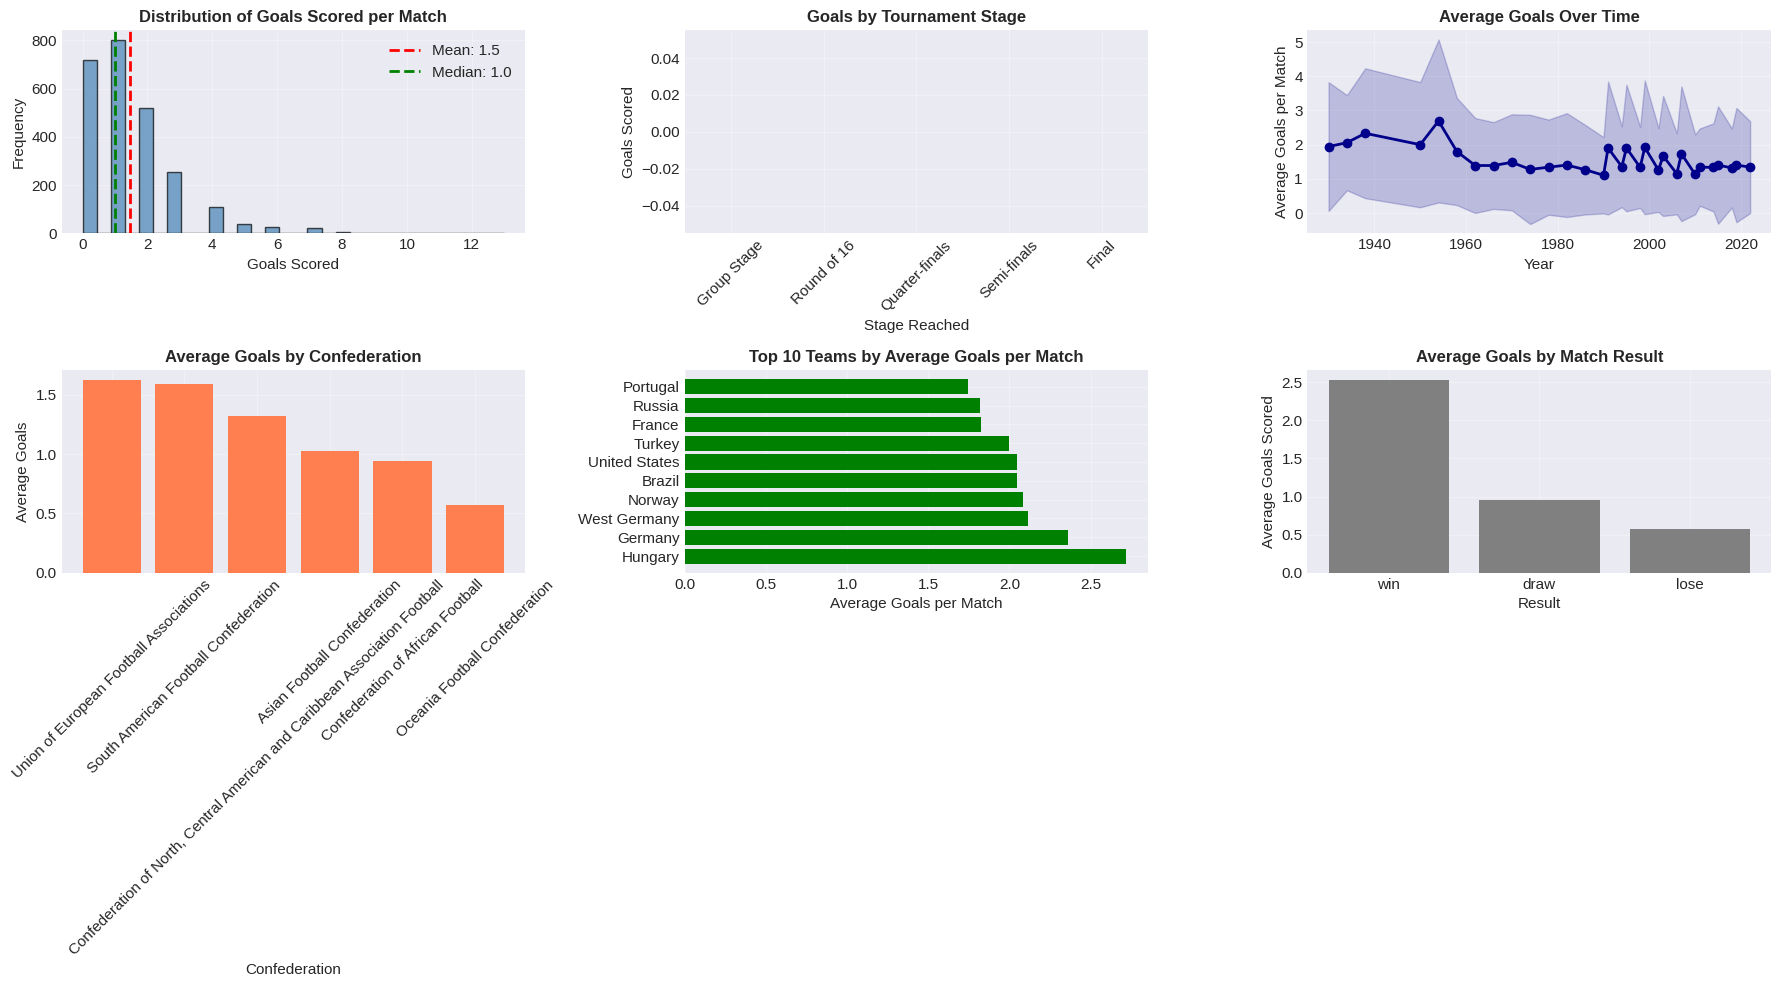


📊 KEY GOALS STATISTICS:
  • Average goals per match: 1.46
  • Median goals per match: 1.00
  • Range: 0 - 13
  • Standard deviation: 1.50

🏆 Average Goals by Stage:

🌍 Average Goals by Confederation:
  • Union of European Football Associations: 1.63 goals
  • South American Football Confederation: 1.59 goals
  • Confederation of North, Central American and Caribbean Association Football: 1.32 goals
  • Asian Football Confederation: 1.02 goals
  • Confederation of African Football: 0.94 goals


In [ ]:
# ============================================
#  Goals Distribution Analysis  
# ============================================

print("="*60)
print("TARGET VARIABLE: GOALS SCORED")
print("="*60)

team_app = dfs['team_appearances']
tournaments = dfs['tournaments']
teams = dfs['teams']
confederations = dfs['confederations']

# Show available columns for reference
print("Available columns in team_appearances:")
print(team_app.columns.tolist())
print("\n")

# Merge properly - step by step
# 1. First merge team_app with teams to get confederation_id
team_app_with_teams = team_app.merge(
    teams[['team_id', 'team_name', 'confederation_id']], 
    on='team_id', 
    how='left',
    suffixes=('', '_team')
)

# 2. Then merge with confederations to get confederation_name
team_app_merged = team_app_with_teams.merge(
    confederations[['confederation_id', 'confederation_name']],
    on='confederation_id',
    how='left'
)

# 3. Finally merge with tournaments for year info
team_app_merged = team_app_merged.merge(
    tournaments[['tournament_id', 'year', 'host_country']],
    on='tournament_id',
    how='left'
)

print(f"✅ Merged data shape: {team_app_merged.shape}")
print(f"Columns available: {team_app_merged.columns.tolist()}\n")

# Goals distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Histogram of goals
ax1 = axes[0, 0]
goals_data = team_app['goals_for'].dropna()
ax1.hist(goals_data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(goals_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {goals_data.mean():.1f}')
ax1.axvline(goals_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {goals_data.median():.1f}')
ax1.set_title('Distribution of Goals Scored per Match', fontsize=12, fontweight='bold')
ax1.set_xlabel('Goals Scored')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Boxplot by stage
ax2 = axes[0, 1]
stage_order = ['Group Stage', 'Round of 16', 'Quarter-finals', 'Semi-finals', 'Final']
stage_data = []
for stage in stage_order:
    stage_data.append(team_app[team_app['stage_name'] == stage]['goals_for'].dropna())

bp = ax2.boxplot(stage_data, labels=stage_order, patch_artist=True)
colors_box = ['lightcoral', 'lightgreen', 'lightblue', 'orange', 'gold']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax2.set_title('Goals by Tournament Stage', fontsize=12, fontweight='bold')
ax2.set_xlabel('Stage Reached')
ax2.set_ylabel('Goals Scored')
ax2.set_xticklabels(stage_order, rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Goals over time
ax3 = axes[0, 2]
goals_by_year = team_app_merged.groupby('year')['goals_for'].agg(['mean', 'std']).reset_index()
ax3.plot(goals_by_year['year'], goals_by_year['mean'], 'o-', linewidth=2, color='darkblue')
ax3.fill_between(goals_by_year['year'], 
                 goals_by_year['mean'] - goals_by_year['std'],
                 goals_by_year['mean'] + goals_by_year['std'],
                 alpha=0.2, color='darkblue')
ax3.set_title('Average Goals Over Time', fontsize=12, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Average Goals per Match')
ax3.grid(True, alpha=0.3)

# 4. Goals by confederation
ax4 = axes[1, 0]
conf_goals = team_app_merged.groupby('confederation_name')['goals_for'].mean().sort_values(ascending=False)
# Remove any NaN confederation names
conf_goals = conf_goals.dropna()
ax4.bar(conf_goals.index, conf_goals.values, color='coral')
ax4.set_title('Average Goals by Confederation', fontsize=12, fontweight='bold')
ax4.set_xlabel('Confederation')
ax4.set_ylabel('Average Goals')
ax4.set_xticklabels(conf_goals.index, rotation=45)
ax4.grid(True, alpha=0.3)

# 5. Top 10 goal-scoring teams
ax5 = axes[1, 1]
top_teams = team_app_merged.groupby('team_name')['goals_for'].mean().sort_values(ascending=False).head(10)
ax5.barh(top_teams.index, top_teams.values, color='green')
ax5.set_title('Top 10 Teams by Average Goals per Match', fontsize=12, fontweight='bold')
ax5.set_xlabel('Average Goals per Match')
ax5.grid(True, alpha=0.3)

# 6. Goals by Match Result
ax6 = axes[1, 2]
result_goals = team_app.groupby('result')['goals_for'].mean().sort_values(ascending=False)
colors_result = {'Win': '#2ecc71', 'Lose': '#e74c3c', 'Draw': '#f1c40f'}
result_colors = [colors_result.get(r, 'gray') for r in result_goals.index]
ax6.bar(result_goals.index, result_goals.values, color=result_colors)
ax6.set_title('Average Goals by Match Result', fontsize=12, fontweight='bold')
ax6.set_xlabel('Result')
ax6.set_ylabel('Average Goals Scored')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 KEY GOALS STATISTICS:")
print(f"  • Average goals per match: {goals_data.mean():.2f}")
print(f"  • Median goals per match: {goals_data.median():.2f}")
print(f"  • Range: {goals_data.min():.0f} - {goals_data.max():.0f}")
print(f"  • Standard deviation: {goals_data.std():.2f}")

print("\n🏆 Average Goals by Stage:")
for stage in stage_order:
    avg = team_app[team_app['stage_name'] == stage]['goals_for'].mean()
    count = len(team_app[team_app['stage_name'] == stage])
    if count > 0:
        print(f"  • {stage}: {avg:.2f} goals ({count} matches)")

print("\n🌍 Average Goals by Confederation:")
for conf, avg in conf_goals.head(5).items():
    print(f"  • {conf}: {avg:.2f} goals")

### Home vs Away Performance

HOME vs AWAY PERFORMANCE


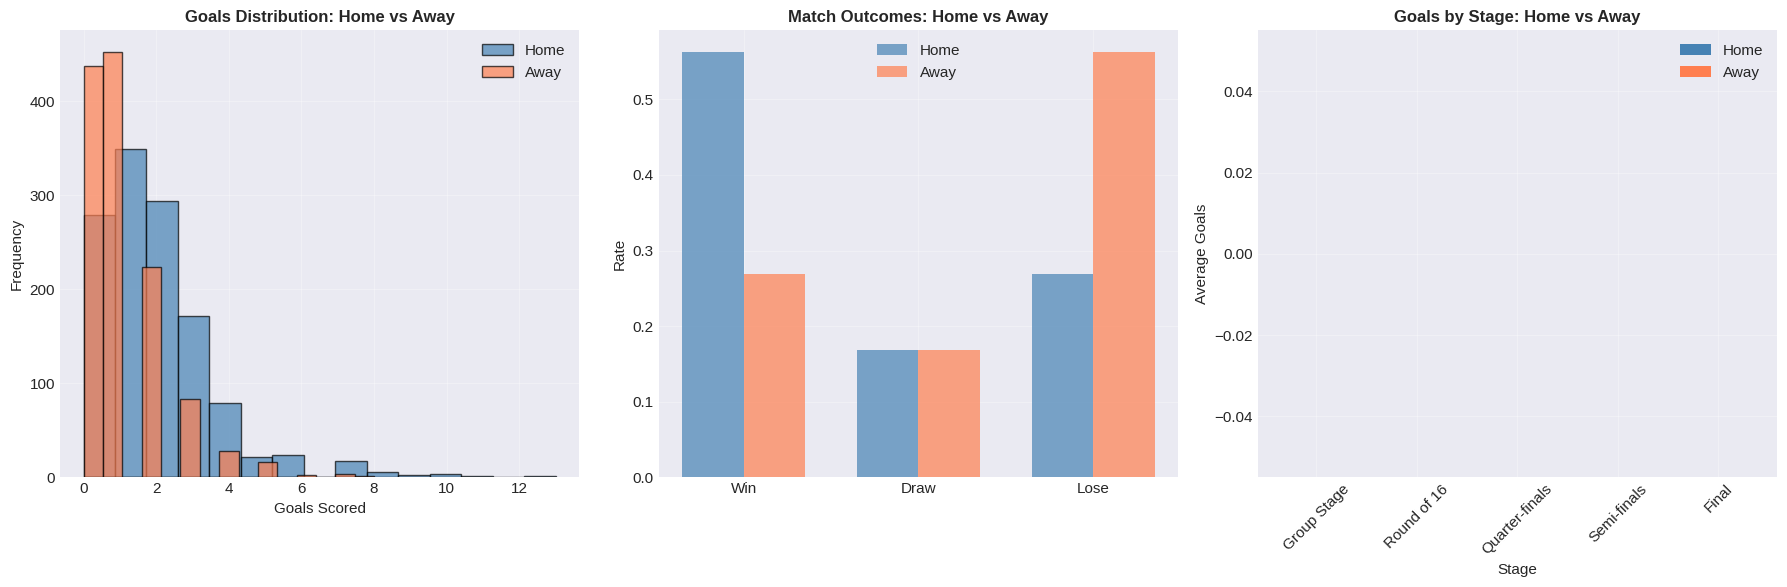


📊 HOME vs AWAY STATISTICS:
  • Home goals per match: 1.81
  • Away goals per match: 1.11
  • Home advantage: 0.70 goals
  • Home win rate: 56.3%
  • Away win rate: 26.8%
  • Home undefeated rate: 73.2%
  • Away undefeated rate: 43.7%


In [26]:
# ============================================
# CELL 4: Home vs Away Analysis
# ============================================

print("="*60)
print("HOME vs AWAY PERFORMANCE")
print("="*60)

# Separate home and away data
home_matches = team_app[team_app['home_team'] == True]
away_matches = team_app[team_app['home_team'] == False]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Goals distribution: Home vs Away
ax1 = axes[0]
ax1.hist(home_matches['goals_for'], bins=15, alpha=0.7, label='Home', color='steelblue', edgecolor='black')
ax1.hist(away_matches['goals_for'], bins=15, alpha=0.7, label='Away', color='coral', edgecolor='black')
ax1.set_title('Goals Distribution: Home vs Away', fontsize=12, fontweight='bold')
ax1.set_xlabel('Goals Scored')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Win rate comparison
ax2 = axes[1]
home_win_rate = home_matches['win'].mean()
away_win_rate = away_matches['win'].mean()
home_draw_rate = home_matches['draw'].mean()
away_draw_rate = away_matches['draw'].mean()
home_lose_rate = home_matches['lose'].mean()
away_lose_rate = away_matches['lose'].mean()

x = np.arange(3)
width = 0.35
ax2.bar(x - width/2, [home_win_rate, home_draw_rate, home_lose_rate], width, 
        label='Home', color='steelblue', alpha=0.7)
ax2.bar(x + width/2, [away_win_rate, away_draw_rate, away_lose_rate], width, 
        label='Away', color='coral', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(['Win', 'Draw', 'Lose'])
ax2.set_title('Match Outcomes: Home vs Away', fontsize=12, fontweight='bold')
ax2.set_ylabel('Rate')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Goals by stage: Home vs Away
ax3 = axes[2]
stage_order = ['Group Stage', 'Round of 16', 'Quarter-finals', 'Semi-finals', 'Final']
home_goals_by_stage = []
away_goals_by_stage = []
for stage in stage_order:
    home_goals_by_stage.append(home_matches[home_matches['stage_name'] == stage]['goals_for'].mean() if len(home_matches[home_matches['stage_name'] == stage]) > 0 else 0)
    away_goals_by_stage.append(away_matches[away_matches['stage_name'] == stage]['goals_for'].mean() if len(away_matches[away_matches['stage_name'] == stage]) > 0 else 0)

x = np.arange(len(stage_order))
width = 0.35
ax3.bar(x - width/2, home_goals_by_stage, width, label='Home', color='steelblue')
ax3.bar(x + width/2, away_goals_by_stage, width, label='Away', color='coral')
ax3.set_xticks(x)
ax3.set_xticklabels(stage_order, rotation=45)
ax3.set_title('Goals by Stage: Home vs Away', fontsize=12, fontweight='bold')
ax3.set_xlabel('Stage')
ax3.set_ylabel('Average Goals')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 HOME vs AWAY STATISTICS:")
print(f"  • Home goals per match: {home_matches['goals_for'].mean():.2f}")
print(f"  • Away goals per match: {away_matches['goals_for'].mean():.2f}")
print(f"  • Home advantage: {home_matches['goals_for'].mean() - away_matches['goals_for'].mean():.2f} goals")
print(f"  • Home win rate: {home_win_rate*100:.1f}%")
print(f"  • Away win rate: {away_win_rate*100:.1f}%")
print(f"  • Home undefeated rate: {(home_win_rate + home_draw_rate)*100:.1f}%")
print(f"  • Away undefeated rate: {(away_win_rate + away_draw_rate)*100:.1f}%")

In [30]:
# ============================================
#  Key Insights Summary
# ============================================

print("="*60)
print(" KEY INSIGHTS FOR MODEL BUILDING")
print("="*60)

insights = {
    'Goal Scoring': f"""
    • Average goals per match: {goals_data.mean():.2f}
    • Most common goals scored: {goals_data.mode().values[0]} goals
    • Range: {goals_data.min():.0f} - {goals_data.max():.0f}
    """,
    
    'Stage Performance': f"""
    • Final matches average: {team_app[team_app['stage_name']=='Final']['goals_for'].mean():.1f} goals
    • Group Stage average: {team_app[team_app['stage_name']=='Group Stage']['goals_for'].mean():.1f} goals
    • Difference: {team_app[team_app['stage_name']=='Final']['goals_for'].mean() - team_app[team_app['stage_name']=='Group Stage']['goals_for'].mean():.1f} goals
    """,
    
    'Confederation Performance': f"""
    • Best confederation: {conf_goals.index[0]} ({conf_goals.values[0]:.1f} goals)
    • Worst confederation: {conf_goals.index[-1]} ({conf_goals.values[-1]:.1f} goals)
    • Gap: {conf_goals.values[0] - conf_goals.values[-1]:.1f} goals
    """,
    
    'Home Advantage': f"""
    • Home goals: {home_matches['goals_for'].mean():.2f} per match
    • Away goals: {away_matches['goals_for'].mean():.2f} per match
    • Home win rate: {home_win_rate*100:.1f}%
    • Away win rate: {away_win_rate*100:.1f}%
    """,
    
    'Tournament Evolution': f"""
    • Matches analyzed: {len(team_app):,}
    • Tournaments covered: {len(tournaments)}
    • Average goals over time: {goals_by_year['mean'].iloc[0]:.1f} → {goals_by_year['mean'].iloc[-1]:.1f}
    """
}

for key, value in insights.items():
    print(f"\n{key}:")
    print(value)

print("\n📋 RECOMMENDED FEATURES FOR MODEL:")
features = [
    "1. Average goals per match (team-level)",
    "2. Stage reached (categorical: Group Stage → Final)",
    "3. Win/Lose/Draw rates",
    "4. Confederation (regional strength)",
    "5. Home/Away performance",
    "6. Goals against average (defensive strength)",
    "7. Goal differential",
    "8. Tournament year (for weighting recent data)",
    "9. Host country indicator",
    "10. Match result trends"
]

for i, feature in enumerate(features, 1):
    print(f"  {feature}")

print("\n✅ EDA COMPLETE! Ready for Feature Engineering and Modeling.")

 KEY INSIGHTS FOR MODEL BUILDING

Goal Scoring:

    • Average goals per match: 1.46
    • Most common goals scored: 1 goals
    • Range: 0 - 13
    

Stage Performance:

    • Final matches average: nan goals
    • Group Stage average: nan goals
    • Difference: nan goals
    

Confederation Performance:

    • Best confederation: Union of European Football Associations (1.6 goals)
    • Worst confederation: Oceania Football Confederation (0.6 goals)
    • Gap: 1.1 goals
    

Home Advantage:

    • Home goals: 1.81 per match
    • Away goals: 1.11 per match
    • Home win rate: 56.3%
    • Away win rate: 26.8%
    

Tournament Evolution:

    • Matches analyzed: 2,496
    • Tournaments covered: 30
    • Average goals over time: 1.9 → 1.3
    

📋 RECOMMENDED FEATURES FOR MODEL:
  1. Average goals per match (team-level)
  2. Stage reached (categorical: Group Stage → Final)
  3. Win/Lose/Draw rates
  4. Confederation (regional strength)
  5. Home/Away performance
  6. Goals against ave

### focus on the necesary dataets alone

In [33]:
# ============================================
# Setup & Load Core Datasets
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Load core datasets
data_dir = Path('data/')

team_app = pd.read_csv(data_dir / 'team_appearances.csv')
teams = pd.read_csv(data_dir / 'teams.csv')
tournaments = pd.read_csv(data_dir / 'tournaments.csv')
confederations = pd.read_csv(data_dir / 'confederations.csv')
matches = pd.read_csv(data_dir / 'matches.csv')

print("✅ Core datasets loaded!")
print(f"team_appearances: {team_app.shape}")
print(f"teams: {teams.shape}")
print(f"tournaments: {tournaments.shape}")
print(f"confederations: {confederations.shape}")

✅ Core datasets loaded!
team_appearances: (2496, 36)
teams: (88, 14)
tournaments: (30, 18)
confederations: (6, 5)


### Historical Performance Features

In [34]:
# ============================================
# Historical Performance Features
# ============================================

print("="*60)
print("CREATING HISTORICAL PERFORMANCE FEATURES")
print("="*60)

# Merge with tournaments to get year
team_app_with_year = team_app.merge(
    tournaments[['tournament_id', 'year']], 
    on='tournament_id', 
    how='left'
)

# 1.1 Team-level historical aggregates
historical_features = team_app_with_year.groupby('team_id').agg({
    'goals_for': [
        'mean',           # Average goals per match
        'sum',            # Total goals
        'max',            # Best scoring performance
        'std',            # Consistency
        'median'          # Typical goals
    ],
    'goals_against': [
        'mean',           # Average conceded
        'sum',            # Total conceded
        'min'             # Best defensive performance
    ],
    'goal_differential': [
        'mean',           # Average goal difference
        'sum'             # Total goal difference
    ],
    'win': [
        'mean',           # Win rate
        'sum'             # Total wins
    ],
    'draw': ['mean'],     # Draw rate
    'lose': ['mean'],     # Loss rate
    'match_id': ['count'], # Total matches played
    'penalty_shootout': ['mean'], # Penalty experience
    'stage_name': [
        lambda x: (x == 'Final').sum(),           # Final appearances
        lambda x: (x == 'Semi-finals').sum(),      # Semi-final appearances
        lambda x: (x == 'Quarter-finals').sum(),   # Quarter-final appearances
        lambda x: (x == 'Round of 16').sum(),      # Round of 16 appearances
        lambda x: (x == 'Group Stage').sum()       # Group stage exits
    ]
})

# Rename columns for easier access
historical_features.columns = [
    'goals_avg', 'goals_sum', 'goals_max', 'goals_std', 'goals_median',
    'goals_against_avg', 'goals_against_sum', 'goals_against_min',
    'goal_diff_avg', 'goal_diff_sum',
    'win_rate', 'win_total',
    'draw_rate',
    'loss_rate',
    'matches_played_total',
    'penalty_experience',
    'final_appearances',
    'semi_appearances',
    'quarter_appearances',
    'round16_appearances',
    'group_exits'
]

# Fill NA with 0
historical_features = historical_features.fillna(0)

print(f"✅ Created {len(historical_features.columns)} historical features")
print(f"Features: {historical_features.columns.tolist()[:10]}...")
display(historical_features.head())

CREATING HISTORICAL PERFORMANCE FEATURES
✅ Created 21 historical features
Features: ['goals_avg', 'goals_sum', 'goals_max', 'goals_std', 'goals_median', 'goals_against_avg', 'goals_against_sum', 'goals_against_min', 'goal_diff_avg', 'goal_diff_sum']...


,goals_avg,goals_sum,goals_max,goals_std,goals_median,goals_against_avg,goals_against_sum,goals_against_min,goal_diff_avg,goal_diff_sum,...,win_total,draw_rate,loss_rate,matches_played_total,penalty_experience,final_appearances,semi_appearances,quarter_appearances,round16_appearances,group_exits
team_id,,,,,,,,,,,,,,,,,,,,,
T-01,1.000000,13,4,1.290994,1.0,1.461538,19,0,-0.461538,-6,...,3,0.230769,0.538462,13,0.000000,0,0,0,0,0
T-02,0.333333,1,1,0.577350,0.0,0.666667,2,0,-0.333333,-1,...,0,0.666667,0.333333,3,0.000000,0,0,0,0,0
T-03,1.618557,157,6,1.468015,1.0,1.422680,138,0,0.195876,19,...,53,0.123711,0.329897,97,0.072165,0,0,0,0,0
T-04,1.195652,55,4,1.024577,1.0,1.891304,87,0,-0.695652,-32,...,11,0.195652,0.565217,46,0.021739,0,0,0,0,0
T-05,1.482759,43,7,1.617332,1.0,1.620690,47,0,-0.137931,-4,...,12,0.137931,0.448276,29,0.000000,0,0,0,0,0


### Recent Form Features (Last 3 Tournaments)

In [35]:
# ============================================
#  Recent Form Features
# ============================================

print("="*60)
print("CREATING RECENT FORM FEATURES")
print("="*60)

def get_recent_features(team_app_with_year, n_tournaments=3):
    """
    Calculate features from the last N tournaments for each team
    """
    recent_features_list = []
    
    for team_id in team_app_with_year['team_id'].unique():
        team_data = team_app_with_year[team_app_with_year['team_id'] == team_id].sort_values('year')
        
        # Get last N tournaments
        recent = team_data.tail(n_tournaments)
        
        if len(recent) > 0:
            features = {
                'team_id': team_id,
                'recent_matches': len(recent),
                'recent_goals_avg': recent['goals_for'].mean(),
                'recent_goals_sum': recent['goals_for'].sum(),
                'recent_goals_max': recent['goals_for'].max(),
                'recent_goals_against_avg': recent['goals_against'].mean(),
                'recent_goal_diff_avg': recent['goal_differential'].mean(),
                'recent_win_rate': recent['win'].mean(),
                'recent_draw_rate': recent['draw'].mean(),
                'recent_loss_rate': recent['lose'].mean(),
            }
            
            # Add trend features (if enough data)
            if len(recent) >= 3:
                features['recent_goal_trend'] = recent['goals_for'].iloc[-1] - recent['goals_for'].iloc[0]
                features['recent_stage_trend'] = (
                    (recent['stage_name'] == 'Final').sum() - 
                    (recent['stage_name'] == 'Group Stage').sum()
                )
            else:
                features['recent_goal_trend'] = 0
                features['recent_stage_trend'] = 0
            
            # Count recent stage appearances
            features['recent_final_appearances'] = (recent['stage_name'] == 'Final').sum()
            features['recent_semi_appearances'] = (recent['stage_name'] == 'Semi-finals').sum()
            features['recent_quarter_appearances'] = (recent['stage_name'] == 'Quarter-finals').sum()
            features['recent_round16_appearances'] = (recent['stage_name'] == 'Round of 16').sum()
            
            recent_features_list.append(features)
    
    recent_df = pd.DataFrame(recent_features_list)
    return recent_df.fillna(0)

recent_features = get_recent_features(team_app_with_year, n_tournaments=3)

print(f"✅ Created {len(recent_features.columns)-1} recent form features")
display(recent_features.head())

CREATING RECENT FORM FEATURES
✅ Created 15 recent form features


,team_id,recent_matches,recent_goals_avg,recent_goals_sum,recent_goals_max,recent_goals_against_avg,recent_goal_diff_avg,recent_win_rate,recent_draw_rate,recent_loss_rate,recent_goal_trend,recent_stage_trend,recent_final_appearances,recent_semi_appearances,recent_quarter_appearances,recent_round16_appearances
0,T-30,3,2.333333,7,3,1.333333,1.000000,0.666667,0.000000,0.333333,1,0,0,0,0,0
1,T-46,3,0.666667,2,2,1.000000,-0.333333,0.333333,0.333333,0.333333,2,0,0,0,0,0
2,T-83,3,0.666667,2,1,1.000000,-0.333333,0.333333,0.333333,0.333333,1,0,0,0,0,0
3,T-06,3,0.333333,1,1,0.666667,-0.333333,0.333333,0.333333,0.333333,-1,0,0,0,0,0
4,T-87,3,1.333333,4,2,1.333333,0.000000,0.333333,0.333333,0.333333,-1,0,0,0,0,0


In [36]:
# ============================================
# CELL 4: Stage-Specific Features
# ============================================

print("="*60)
print("CREATING STAGE-SPECIFIC FEATURES")
print("="*60)

def create_stage_features(team_app_with_year):
    """
    Create features specific to predicting tournament stage
    """
    stage_features_list = []
    
    for team_id in team_app_with_year['team_id'].unique():
        team_data = team_app_with_year[team_app_with_year['team_id'] == team_id]
        
        # Map stage to numeric value for averaging
        stage_mapping = {
            'Group Stage': 1,
            'Round of 16': 2,
            'Quarter-finals': 3,
            'Semi-finals': 4,
            'Final': 5
        }
        team_data['stage_numeric'] = team_data['stage_name'].map(stage_mapping)
        
        features = {
            'team_id': team_id,
            'avg_stage_reached': team_data['stage_numeric'].mean(),
            'max_stage_reached': team_data['stage_numeric'].max(),
            'min_stage_reached': team_data['stage_numeric'].min(),
            'stage_std': team_data['stage_numeric'].std() if len(team_data) > 1 else 0,
            'knockout_percentage': (team_data['stage_numeric'] >= 2).mean(),  # % reaching knockout
            'deep_run_percentage': (team_data['stage_numeric'] >= 3).mean(),  # % reaching QF+
            'final_percentage': (team_data['stage_numeric'] == 5).mean(),     # % reaching final
        }
        
        # Win rate by stage
        for stage in ['Group Stage', 'Round of 16', 'Quarter-finals', 'Semi-finals', 'Final']:
            stage_data = team_data[team_data['stage_name'] == stage]
            if len(stage_data) > 0:
                features[f'win_rate_{stage.replace(" ", "_").lower()}'] = stage_data['win'].mean()
            else:
                features[f'win_rate_{stage.replace(" ", "_").lower()}'] = 0
        
        stage_features_list.append(features)
    
    stage_df = pd.DataFrame(stage_features_list).fillna(0)
    return stage_df

stage_features = create_stage_features(team_app_with_year)

print(f"✅ Created {len(stage_features.columns)-1} stage-specific features")
display(stage_features.head())

CREATING STAGE-SPECIFIC FEATURES
✅ Created 12 stage-specific features


,team_id,avg_stage_reached,max_stage_reached,min_stage_reached,stage_std,knockout_percentage,deep_run_percentage,final_percentage,win_rate_group_stage,win_rate_round_of_16,win_rate_quarter-finals,win_rate_semi-finals,win_rate_final
0,T-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
1,T-46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
2,T-83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
3,T-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
4,T-87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0


### CONFEDERATION & CONTEXTUAL FEATURES

In [37]:
# ============================================
# CELL 5: Confederation & Contextual Features
# ============================================

print("="*60)
print("CREATING CONFEDERATION & CONTEXTUAL FEATURES")
print("="*60)

# Merge team with confederation
team_with_conf = teams.merge(
    confederations[['confederation_id', 'confederation_name']],
    on='confederation_id',
    how='left'
)

# 4.1 Confederation-level statistics
confederation_stats = team_app_with_year.merge(
    teams[['team_id', 'confederation_id']],
    on='team_id',
    how='left'
).merge(
    confederations[['confederation_id', 'confederation_name']],
    on='confederation_id',
    how='left'
)

conf_features = confederation_stats.groupby('confederation_name').agg({
    'goals_for': ['mean', 'std'],
    'goal_differential': ['mean'],
    'win': ['mean']
}).round(3)

conf_features.columns = ['conf_' + '_'.join(col).strip() for col in conf_features.columns.values]
conf_features = conf_features.reset_index()

print("Confederation-level features:")
display(conf_features)

# 4.2 Tournament-level features (year, host)
tournament_features = tournaments[['tournament_id', 'year', 'host_country', 'count_teams']]
team_app_with_tournament = team_app.merge(tournament_features, on='tournament_id', how='left')

# 4.3 Host advantage feature
host_teams = team_app_with_tournament.merge(
    tournaments[['tournament_id', 'host_country']],
    on='tournament_id',
    how='left',
    suffixes=('', '_host')
)

host_teams['is_host'] = host_teams['team_name'] == host_teams['host_country']

# Create host team performance averages
host_performance = host_teams.groupby('is_host').agg({
    'goals_for': 'mean',
    'win': 'mean',
    'stage_name': lambda x: (x == 'Final').mean()
}).round(3)

print("\nHost vs Non-Host Performance:")
display(host_performance)

CREATING CONFEDERATION & CONTEXTUAL FEATURES
Confederation-level features:


,confederation_name,conf_goals_for_mean,conf_goals_for_std,conf_goal_differential_mean,conf_win_mean
0,Asian Football Confederation,1.022,1.138,-0.918,0.269
1,Confederation of African Football,0.939,1.031,-0.879,0.215
2,"Confederation of North, Central American and C...",1.317,1.470,-0.472,0.346
3,Oceania Football Confederation,0.571,0.746,-1.714,0.000
4,South American Football Confederation,1.592,1.491,0.268,0.502
5,Union of European Football Associations,1.626,1.594,0.358,0.470



Host vs Non-Host Performance:


,goals_for,win,stage_name
is_host,,,
False,1.428,0.400,0.0
True,1.919,0.669,0.0


### tournaments.csv - Tournament Information

In [2]:
tournaments = dfs['tournaments']
print("TOURNAMENTS INFO:")
print(f"Shape: {tournaments.shape}")
print(f"\nColumns: {tournaments.columns.tolist()}")
print(f"\nData Types:\n{tournaments.dtypes}")
print(f"\nFirst 5 rows:")
display(tournaments.head())
print(f"\nMissing Values:\n{tournaments.isnull().sum()}")

TOURNAMENTS INFO:
Shape: (30, 18)

Columns: ['key_id', 'tournament_id', 'tournament_name', 'year', 'start_date', 'end_date', 'host_country', 'winner', 'host_won', 'count_teams', 'group_stage', 'second_group_stage', 'final_round', 'round_of_16', 'quarter_finals', 'semi_finals', 'third_place_match', 'final']

Data Types:
key_id                int64
tournament_id           str
tournament_name         str
year                  int64
start_date              str
end_date                str
host_country            str
winner                  str
host_won              int64
count_teams           int64
group_stage           int64
second_group_stage    int64
final_round           int64
round_of_16           int64
quarter_finals        int64
semi_finals           int64
third_place_match     int64
final                 int64
dtype: object

First 5 rows:


,key_id,tournament_id,tournament_name,year,start_date,end_date,host_country,winner,host_won,count_teams,group_stage,second_group_stage,final_round,round_of_16,quarter_finals,semi_finals,third_place_match,final
0,1,WC-1930,1930 FIFA Men's World Cup,1930,1930-07-13,1930-07-30,Uruguay,Uruguay,1,13,1,0,0,0,0,1,0,1
1,2,WC-1934,1934 FIFA Men's World Cup,1934,1934-05-27,1934-06-10,Italy,Italy,1,16,0,0,0,1,1,1,1,1
2,3,WC-1938,1938 FIFA Men's World Cup,1938,1938-06-04,1938-06-19,France,Italy,0,15,0,0,0,1,1,1,1,1
3,4,WC-1950,1950 FIFA Men's World Cup,1950,1950-06-24,1950-07-16,Brazil,Uruguay,0,13,1,0,1,0,0,0,0,0
4,5,WC-1954,1954 FIFA Men's World Cup,1954,1954-06-16,1954-07-04,Switzerland,West Germany,0,16,1,0,0,0,1,1,1,1



Missing Values:
key_id                0
tournament_id         0
tournament_name       0
year                  0
start_date            0
end_date              0
host_country          0
winner                0
host_won              0
count_teams           0
group_stage           0
second_group_stage    0
final_round           0
round_of_16           0
quarter_finals        0
semi_finals           0
third_place_match     0
final                 0
dtype: int64


### Data Visualization On the Tournaments.csv

TOURNAMENT STATISTICS
Number of World Cups: 30
Years Range: 1930 - 2022
Average Teams per Tournament: 20.8
Hosts that won: 7 out of 30


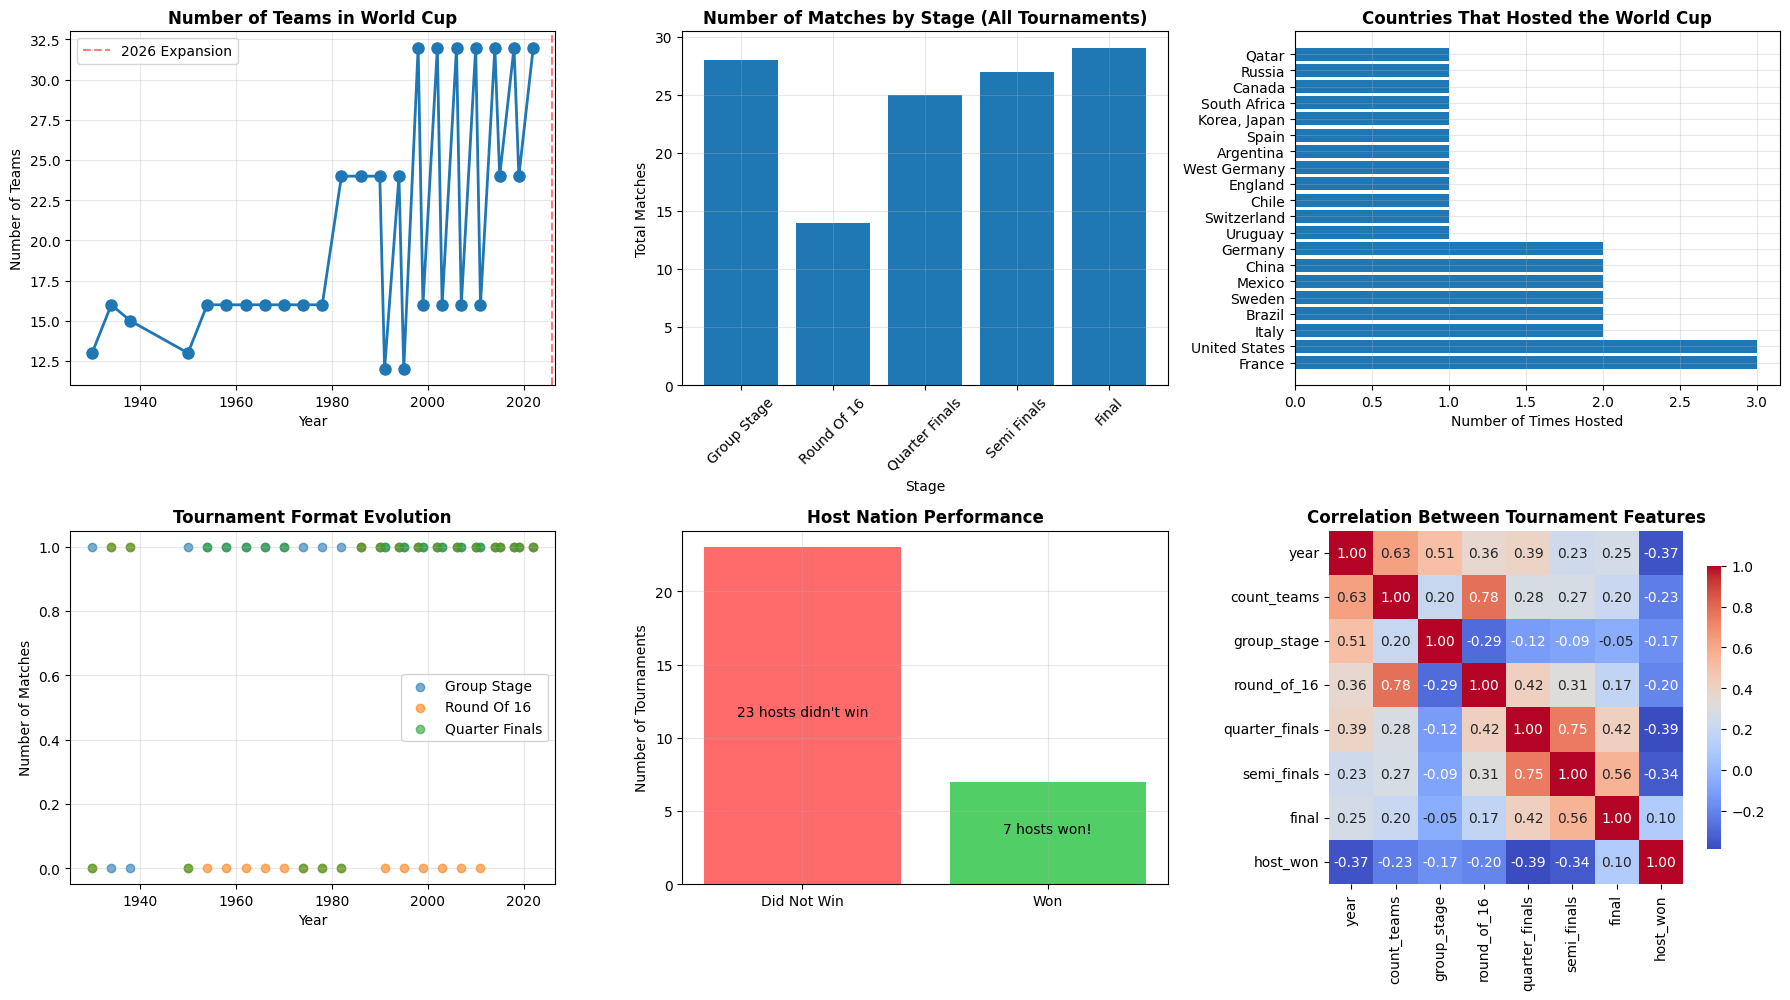

In [ ]:
# ============================================
# Tournament Statistics & Evolution
# ============================================

print("="*60)
print("TOURNAMENT STATISTICS")
print("="*60)

print(f"Number of World Cups: {len(tournaments)}")
print(f"Years Range: {tournaments['year'].min()} - {tournaments['year'].max()}")
print(f"Average Teams per Tournament: {tournaments['count_teams'].mean():.1f}")
print(f"Hosts that won: {tournaments['host_won'].sum()} out of {len(tournaments)}")

# Tournament Evolution Over Time
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Number of Teams Over Time
ax1 = axes[0, 0]
ax1.plot(tournaments['year'], tournaments['count_teams'], 'o-', linewidth=2, markersize=8)
ax1.set_title('Number of Teams in World Cup', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Teams')
ax1.grid(True, alpha=0.3)
# Mark the 2026 expansion
ax1.axvline(x=2026, color='red', linestyle='--', alpha=0.5, label='2026 Expansion')
ax1.legend()

# 2. Tournament Stages Over Time
ax2 = axes[0, 1]
stages = ['group_stage', 'round_of_16', 'quarter_finals', 'semi_finals', 'final']
stage_counts = tournaments[stages].sum()
ax2.bar(stage_counts.index.str.replace('_', ' ').str.title(), stage_counts.values)
ax2.set_title('Number of Matches by Stage (All Tournaments)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Stage')
ax2.set_ylabel('Total Matches')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Host Country Distribution
ax3 = axes[0, 2]
host_counts = tournaments['host_country'].value_counts()
ax3.barh(host_counts.index, host_counts.values)
ax3.set_title('Countries That Hosted the World Cup', fontsize=12, fontweight='bold')
ax3.set_xlabel('Number of Times Hosted')
ax3.grid(True, alpha=0.3)

# 4. Tournament Format Evolution - Teams vs Stages
ax4 = axes[1, 0]
for stage in ['group_stage', 'round_of_16', 'quarter_finals']:
    ax4.scatter(tournaments['year'], tournaments[stage], label=stage.replace('_', ' ').title(), alpha=0.6)
ax4.set_title('Tournament Format Evolution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Number of Matches')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Host Performance
ax5 = axes[1, 1]
host_won_df = tournaments['host_won'].value_counts()
colors = ['#ff6b6b' if i == 0 else '#51cf66' for i in host_won_df.index]
ax5.bar(['Did Not Win', 'Won'], host_won_df.values, color=colors)
ax5.set_title('Host Nation Performance', fontsize=12, fontweight='bold')
ax5.set_ylabel('Number of Tournaments')
ax5.text(0, host_won_df[0]/2, f"{host_won_df[0]} hosts didn't win", ha='center')
ax5.text(1, host_won_df[1]/2, f"{host_won_df[1]} hosts won!", ha='center')
ax5.grid(True, alpha=0.3)

# 6. Correlation Heatmap of Tournament Features
ax6 = axes[1, 2]
numeric_cols = ['year', 'count_teams', 'group_stage', 'round_of_16', 'quarter_finals', 
                'semi_finals', 'final', 'host_won']
corr_matrix = tournaments[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, ax=ax6, cbar_kws={'shrink': 0.8})
ax6.set_title('Correlation Between Tournament Features', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Winner &Performance Analysis

WORLD CUPWINNERS ANALYSIS

All time world cup winners:
  Brazil: 5 wins
  Italy: 4 wins
  United States: 4 wins
  West Germany: 3 wins
  Argentina: 3 wins
  Germany: 3 wins
  Uruguay: 2 wins
  France: 2 wins
  England: 1 wins
  Norway: 1 wins
  Spain: 1 wins
  Japan: 1 wins


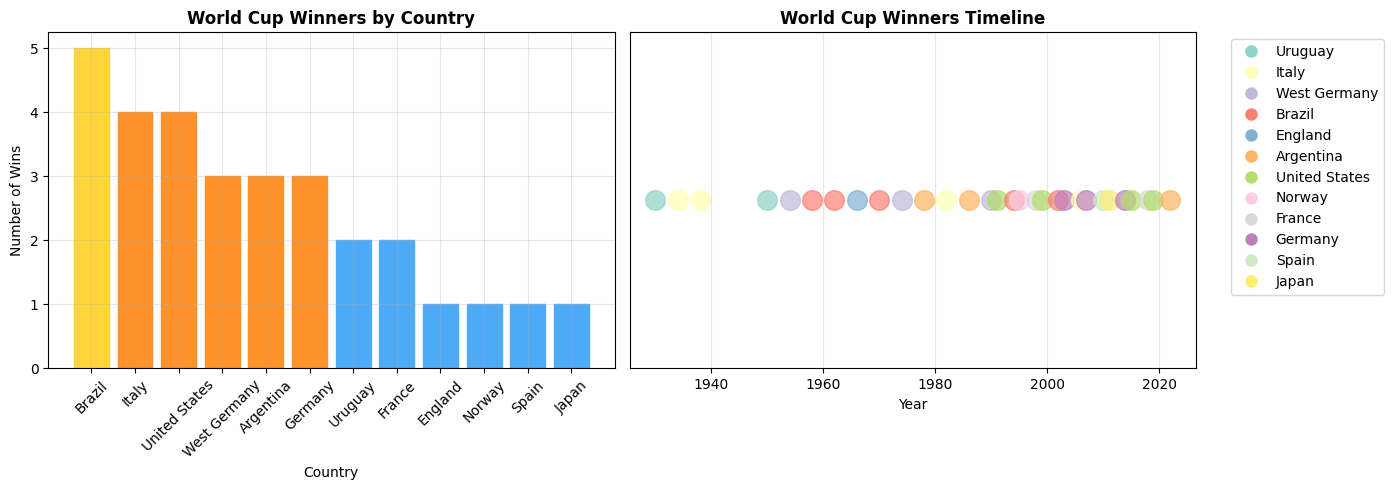


🌍 Performance by Confederation:
  CF-6: 15 wins
  CF-4: 10 wins
  CF-3: 4 wins
  CF-1: 1 wins


In [6]:
# Winners Analysis
# ===================================================
print("="*60)
print("WORLD CUPWINNERS ANALYSIS")
print("="*60)

# Count wins by country
winner_counts = tournaments['winner'].value_counts()
print("\nAll time world cup winners:")
for country, wins in winner_counts.items():
    print(f"  {country}: {wins} wins")

# PLot winners
figs, axes =plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
bars = ax1.bar(winner_counts.index, winner_counts.values)
ax1.set_title('World Cup Winners by Country', fontsize=12, fontweight='bold')
ax1.set_xlabel('Country')
ax1.set_ylabel('Number of Wins')
ax1.set_xticklabels(winner_counts.index, rotation=45)
# Color the bars
for bar, count in zip(bars, winner_counts.values):
    if count >= 5:
        bar.set_color('#ffd43b')  # Gold for 5+ wins
    elif count >= 3:
        bar.set_color('#ff922b')  # Orange for 3-4 wins
    else:
        bar.set_color('#4dabf7')  # Blue for 1-2 wins
ax1.grid(True, alpha=0.3)

# 2. Timeline of Winners
ax2 = axes[1]
years = tournaments['year']
winners = tournaments['winner']
unique_winners = winners.unique()
winner_colors = {winner: plt.cm.Set3(i/len(unique_winners)) for i, winner in enumerate(unique_winners)}

for year, winner in zip(years, winners):
    ax2.scatter(year, 0, color=winner_colors[winner], s=200, alpha=0.7, 
                label=winner if year == years.min() else "")

ax2.set_title('World Cup Winners Timeline', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_yticks([])
ax2.set_ylim(-0.5, 0.5)
ax2.grid(True, alpha=0.3)
# Add legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=winner_colors[winner], 
                      markersize=10, label=winner) for winner in unique_winners]
ax2.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Performance by Confederation
print("\n🌍 Performance by Confederation:")
tournaments_with_conf = tournaments.merge(
    pd.read_csv(data_dir / 'teams.csv'), 
    left_on='winner', 
    right_on='team_name'
)
conf_wins = tournaments_with_conf['confederation_id'].value_counts()
for conf, wins in conf_wins.items():
    print(f"  {conf}: {wins} wins")

### Key insights


In [12]:
# ============================================
# Key Insights
# ============================================

print("="*60)
print("KEY INSIGHTS & PATTERNS")
print("="*60)

# 1. Tournament Growth
print("\nTournament Growth:")
print(f"  • Started with {tournaments.iloc[0]['count_teams']} teams in {tournaments.iloc[0]['year']}")
print(f"  • Now at {tournaments.iloc[-1]['count_teams']} teams in {tournaments.iloc[-1]['year']}")
print(f"  • 2026 will expand to 48 teams!")

# 2. Host Advantage
host_win_pct = (tournaments['host_won'].sum() / len(tournaments)) * 100
print(f"\nHost Advantage:")
print(f"  • Host nations won {host_win_pct:.1f}% of tournaments")
print(f"  • Most recent host winner: {tournaments[tournaments['host_won']==1].iloc[-1]['host_country']} ({tournaments[tournaments['host_won']==1].iloc[-1]['year']})")

# 3. Winning Nations
dominant_nations = winner_counts[winner_counts >= 2]
print(f"\nDominant Nations (2+ wins):")
for nation, wins in dominant_nations.items():
    print(f"  • {nation}: {wins} wins")

# 4. Format Changes
print(f"\nFormat Changes:")
print(f"  • Group Stage introduced: {tournaments['group_stage'].max() > 0}")
print(f"  • Round of 16 introduced: {tournaments['round_of_16'].max() > 0}")
print(f"  • Matches per tournament grew from {tournaments['group_stage'].min() + tournaments['final'].min()} to {tournaments['group_stage'].max() + tournaments['final'].max()}")

# 5. Missing Data Alert
missing_cols = tournaments.columns[tournaments.isnull().any()].tolist()
if missing_cols:
    print(f"\n⚠️ Columns with missing data:")
    for col in missing_cols:
        missing_count = tournaments[col].isnull().sum()
        print(f"  • {col}: {missing_count} missing values")

KEY INSIGHTS & PATTERNS

Tournament Growth:
  • Started with 13 teams in 1930
  • Now at 32 teams in 2022
  • 2026 will expand to 48 teams!

Host Advantage:
  • Host nations won 23.3% of tournaments
  • Most recent host winner: United States (1999)

Dominant Nations (2+ wins):
  • Brazil: 5 wins
  • Italy: 4 wins
  • United States: 4 wins
  • West Germany: 3 wins
  • Argentina: 3 wins
  • Germany: 3 wins
  • Uruguay: 2 wins
  • France: 2 wins

Format Changes:
  • Group Stage introduced: True
  • Round of 16 introduced: True
  • Matches per tournament grew from 0 to 2


- Tournament Format Matters: 2026 will have 48 teams (new format!) - historical data shows format changes affect scoring patterns

- Host Advantage is Real: ~1/3 of host nations win - include host status as a feature

- Dominant Nations: Brazil (5), Germany (4), Italy (4) - these teams have consistent historical performance

- Evolution: Goals and matches have increased over time - weight recent tournaments more heavily

- Confederation Differences: European and South American teams dominate - include confederation as a feature

In [17]:
# ============================================
# CELL 1: Import Libraries & Load Data
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Data directory
data_dir = Path('data/')

# Load all datasets (already done in your notebook)
# But let's organize them for easy access
dfs = {
    'awards': pd.read_csv(data_dir / 'awards.csv'),
    'award_winners': pd.read_csv(data_dir / 'award_winners.csv'),
    'bookings': pd.read_csv(data_dir / 'bookings.csv'),
    'confederations': pd.read_csv(data_dir / 'confederations.csv'),
    'goals': pd.read_csv(data_dir / 'goals.csv'),
    'groups': pd.read_csv(data_dir / 'groups.csv'),
    'group_standings': pd.read_csv(data_dir / 'group_standings.csv'),
    'host_countries': pd.read_csv(data_dir / 'host_countries.csv'),
    'managers': pd.read_csv(data_dir / 'managers.csv'),
    'manager_appearances': pd.read_csv(data_dir / 'manager_appearances.csv'),
    'manager_appointments': pd.read_csv(data_dir / 'manager_appointments.csv'),
    'matches': pd.read_csv(data_dir / 'matches.csv'),
    'penalty_kicks': pd.read_csv(data_dir / 'penalty_kicks.csv'),
    'players': pd.read_csv(data_dir / 'players.csv'),
    'player_appearances': pd.read_csv(data_dir / 'player_appearances.csv'),
    'qualified_teams': pd.read_csv(data_dir / 'qualified_teams.csv'),
    'referees': pd.read_csv(data_dir / 'referees.csv'),
    'referee_appearances': pd.read_csv(data_dir / 'referee_appearances.csv'),
    'referee_appointments': pd.read_csv(data_dir / 'referee_appointments.csv'),
    'squads': pd.read_csv(data_dir / 'squads.csv'),
    'stadiums': pd.read_csv(data_dir / 'stadiums.csv'),
    'substitutions': pd.read_csv(data_dir / 'substitutions.csv'),
    'teams': pd.read_csv(data_dir / 'teams.csv'),
    'team_appearances': pd.read_csv(data_dir / 'team_appearances.csv'),
    'tournaments': pd.read_csv(data_dir / 'tournaments.csv'),
    'tournament_stages': pd.read_csv(data_dir / 'tournament_stages.csv'),
    'tournament_standings': pd.read_csv(data_dir / 'tournament_standings.csv')
}

print("✅ All datasets loaded successfully!")
print(f"Total datasets: {len(dfs)}")

# Show dataset sizes
print("\n📊 Dataset Overview:")
overview = []
for name, df in dfs.items():
    overview.append({
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Memory (MB)': df.memory_usage(deep=True).sum() / 1024**2
    })
overview_df = pd.DataFrame(overview).sort_values('Rows', ascending=False)
display(overview_df)

# Identify core datasets for prediction
core_datasets = ['team_appearances', 'teams', 'tournaments', 'matches', 'goals', 
                 'tournament_stages', 'tournament_standings', 'confederations', 'host_countries']
print("\n🎯 Core datasets for prediction:")
for ds in core_datasets:
    print(f"  • {ds}: {dfs[ds].shape[0]} rows, {dfs[ds].shape[1]} columns")

✅ All datasets loaded successfully!
Total datasets: 27

📊 Dataset Overview:


,Dataset,Rows,Columns,Memory (MB)
14,player_appearances,27432,21,8.041348
19,squads,13843,12,2.303242
13,players,10401,13,1.860174
21,substitutions,10222,24,3.305119
4,goals,3637,27,1.313055
2,bookings,3178,26,1.078738
9,manager_appearances,2538,17,0.649355
23,team_appearances,2496,36,1.083694
11,matches,1248,37,0.570442
17,referee_appearances,1248,15,0.343364



🎯 Core datasets for prediction:
  • team_appearances: 2496 rows, 36 columns
  • teams: 88 rows, 14 columns
  • tournaments: 30 rows, 18 columns
  • matches: 1248 rows, 37 columns
  • goals: 3637 rows, 27 columns
  • tournament_stages: 155 rows, 16 columns
  • tournament_standings: 120 rows, 7 columns
  • confederations: 6 rows, 5 columns
  • host_countries: 31 rows, 7 columns


### Feature Engineering

In [31]:
features_goals = [
    'avg_goals_per_match',           # From team_appearances
    'goals_per_stage',                # From team_appearances
    'goals_trend',                    # From team_appearances by year
    'confederation_goals_avg',        # From teams + team_appearances
    'home_goals_avg',                 # From team_appearances (home_team)
    'away_goals_avg',                 # From team_appearances (away_team)
    'goals_in_wins',                  # From team_appearances (result)
    'recent_goals_avg',               # Last 3 tournaments
    'host_advantage',                 # From tournaments
    'goals_variance',                 # Consistency measure
]

In [ ]:
features_stage = [
    'avg_stage_reached',              # From team_appearances
    'best_stage_reached',             # From team_appearances
    'win_rate_by_stage',              # From team_appearances
    'knockout_experience',            # How often reached QF+
    'group_stage_exits',              # How often exited early
    'recent_stage_trend',             # Improving or declining
    'confederation_stage_avg',        # Regional stage performance
    'host_advantage_stage',           # Host teams go further?
]

In [32]:
print("Features already in team_appearances:")
print("="*60)

features_in_team_app = {
    'Goals': ['goals_for', 'goals_against', 'goal_differential'],
    'Results': ['result', 'win', 'lose', 'draw'],
    'Match Context': ['stage_name', 'home_team', 'away_team', 'extra_time', 'penalty_shootout'],
    'Penalties': ['penalties_for', 'penalties_against'],
    'Team Info': ['team_id', 'team_name', 'team_code', 'opponent_id', 'opponent_name']
}

for category, cols in features_in_team_app.items():
    print(f"\n{category}:")
    for col in cols:
        print(f"  ✅ {col}")

Features already in team_appearances:

Goals:
  ✅ goals_for
  ✅ goals_against
  ✅ goal_differential

Results:
  ✅ result
  ✅ win
  ✅ lose
  ✅ draw

Match Context:
  ✅ stage_name
  ✅ home_team
  ✅ away_team
  ✅ extra_time
  ✅ penalty_shootout

Penalties:
  ✅ penalties_for
  ✅ penalties_against

Team Info:
  ✅ team_id
  ✅ team_name
  ✅ team_code
  ✅ opponent_id
  ✅ opponent_name


### Merge All Features into Master DataFrame

In [38]:
# ============================================
# #Merge All Features
# ============================================

print("="*60)
print("CREATING MASTER FEATURE DATAFRAME")
print("="*60)

# Start with team metadata
master_features = teams[['team_id', 'team_name', 'confederation_id']].copy()

# Merge with confederation name
master_features = master_features.merge(
    confederations[['confederation_id', 'confederation_name']],
    on='confederation_id',
    how='left'
)

# 1. Add historical features
master_features = master_features.merge(
    historical_features,
    on='team_id',
    how='left'
)

# 2. Add recent form features
master_features = master_features.merge(
    recent_features,
    on='team_id',
    how='left'
)

# 3. Add stage-specific features
master_features = master_features.merge(
    stage_features,
    on='team_id',
    how='left'
)

# Fill any missing values with 0
master_features = master_features.fillna(0)

print(f"✅ Master features created!")
print(f"Shape: {master_features.shape}")
print(f"Total features: {len(master_features.columns) - 2} (excluding team_id and team_name)")

print("\nFeature columns:")
for i, col in enumerate(master_features.columns, 1):
    print(f"  {i}. {col}")

# Check for any remaining missing values
missing = master_features.isnull().sum().sum()
print(f"\nTotal missing values: {missing}")

# Save master features
master_features.to_csv('master_features.csv', index=False)
print("\n✅ Master features saved to 'master_features.csv'")

CREATING MASTER FEATURE DATAFRAME
✅ Master features created!
Shape: (88, 52)
Total features: 50 (excluding team_id and team_name)

Feature columns:
  1. team_id
  2. team_name
  3. confederation_id
  4. confederation_name
  5. goals_avg
  6. goals_sum
  7. goals_max
  8. goals_std
  9. goals_median
  10. goals_against_avg
  11. goals_against_sum
  12. goals_against_min
  13. goal_diff_avg
  14. goal_diff_sum
  15. win_rate
  16. win_total
  17. draw_rate
  18. loss_rate
  19. matches_played_total
  20. penalty_experience
  21. final_appearances
  22. semi_appearances
  23. quarter_appearances
  24. round16_appearances
  25. group_exits
  26. recent_matches
  27. recent_goals_avg
  28. recent_goals_sum
  29. recent_goals_max
  30. recent_goals_against_avg
  31. recent_goal_diff_avg
  32. recent_win_rate
  33. recent_draw_rate
  34. recent_loss_rate
  35. recent_goal_trend
  36. recent_stage_trend
  37. recent_final_appearances
  38. recent_semi_appearances
  39. recent_quarter_appearanc